Horizontal and Vertical sums of vorticity as shown in Mark

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm

#####Import Ollie Tools
dirPath = "C:/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)


####Import Ollie Tools MAC
# dirPath = "/Users/olliejackson/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)

oj.thesis_plot_settings()


# h5file = h5py.File('E:/H5/meandataVLSFine.h5', 'r')
h5file = h5py.File('E:/H5/meandataVLS.h5', 'r')
# h5file = h5py.File('E:/H5/WideFOV.h5', 'r')

vels = h5file['Narrow']['U100']['L100']['RPM0']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
u, v = oj.scaleVelNozzle(u, v, 90) #make suer to change this for the wide fov data
u, v = u/0.1, v/0.1 
r_nd, z_nd = oj.NDUnitsForPlotsNozzle(u.shape[1], u.shape[2])
Time = oj.frames_to_seconds(u, v, 90)
vort, vort_gauss = oj.calculate_vorticity(u,v)
h5file.close()

C:/Coding/Code
C:/Coding
Thesis plot settings applied


[Text(0, -2.0, ''),
 Text(0, 0.0, ''),
 Text(0, 2.0, ''),
 Text(0, 4.0, ''),
 Text(0, 6.0, ''),
 Text(0, 8.0, ''),
 Text(0, 10.0, '')]

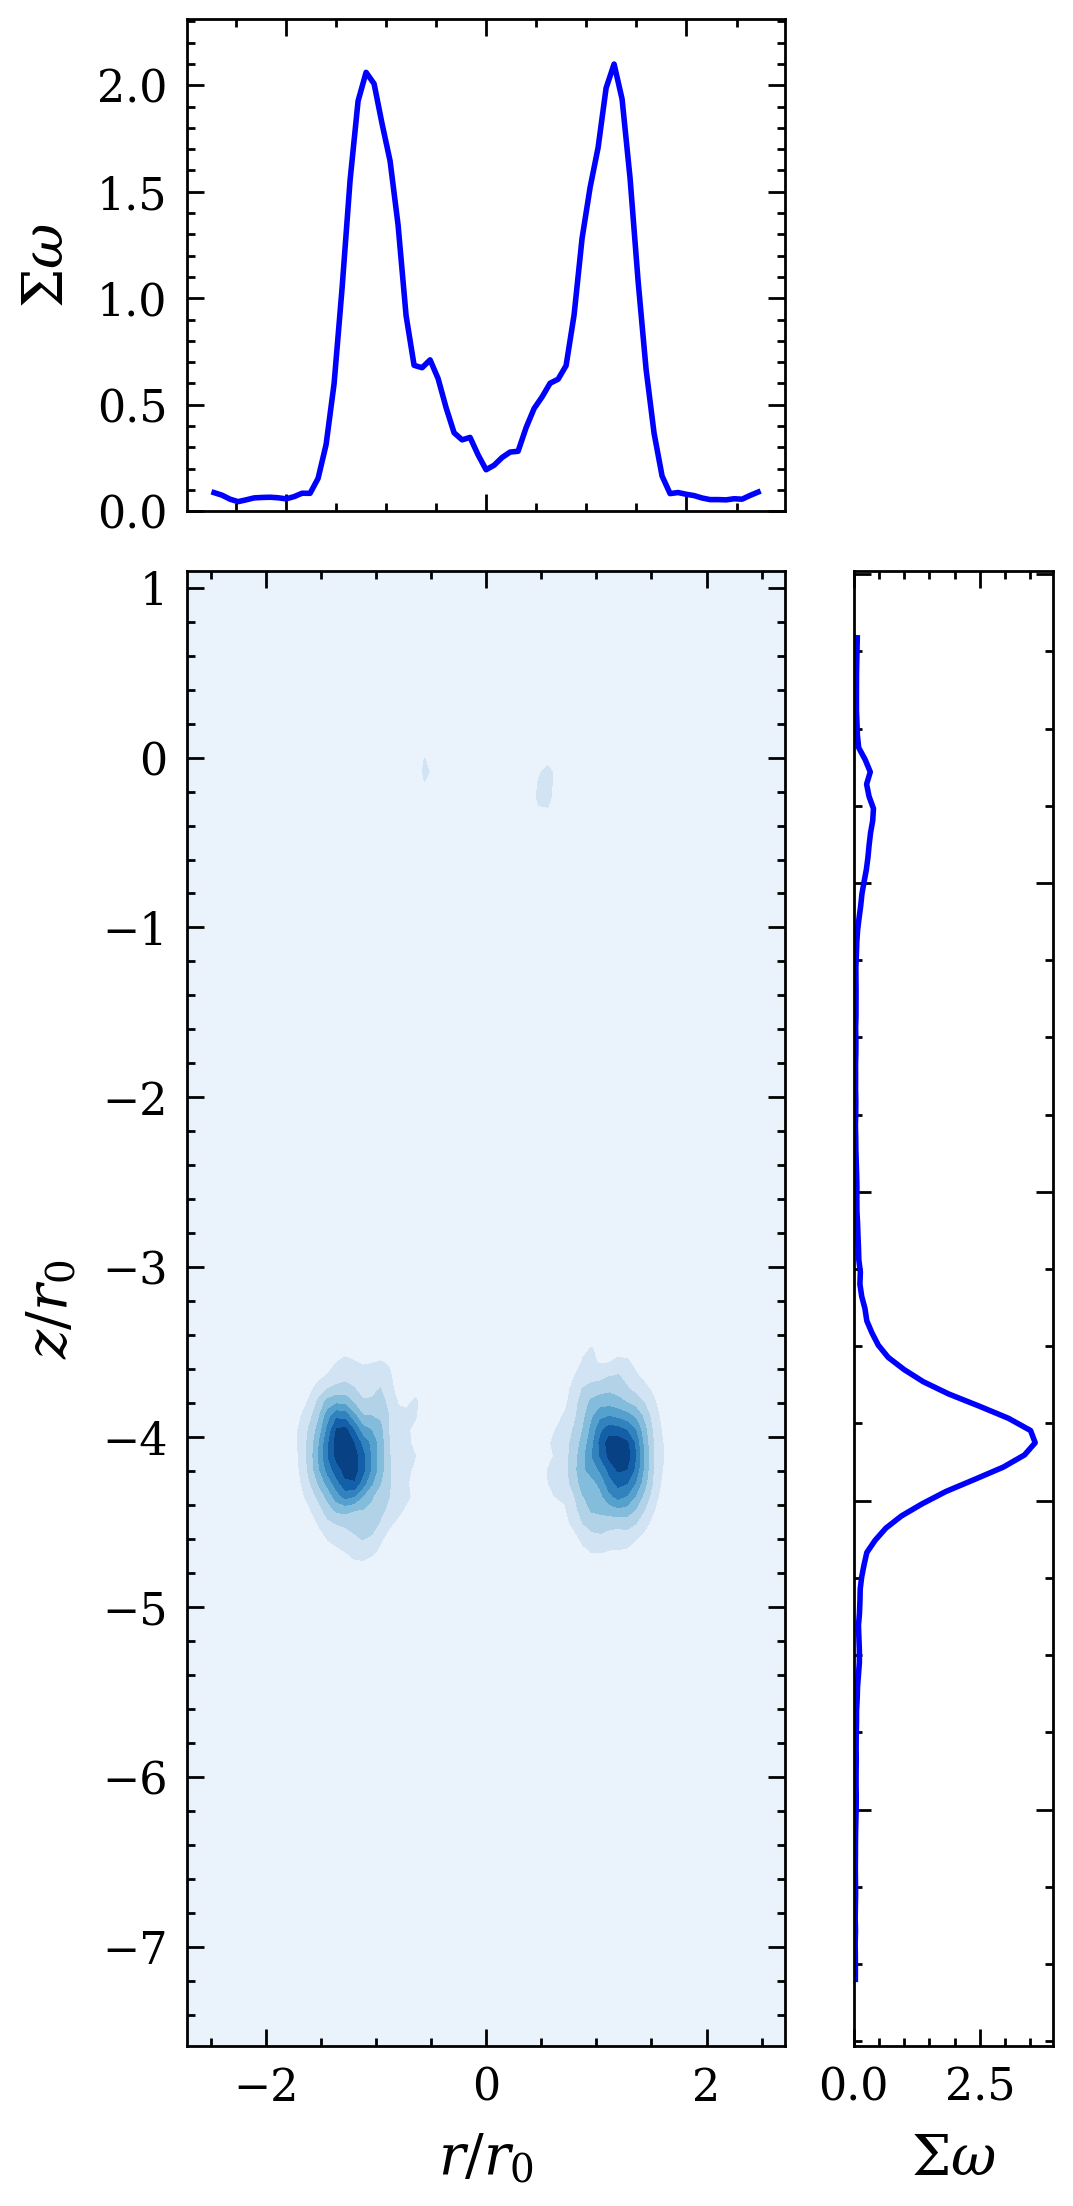

In [2]:
frame = 350 #12rpm
frame = 450 #0rpm

vert_sum = np.sum(abs(vort), 1)
horiz_sum = np.sum(abs(vort), 2)

norm = colors.TwoSlopeNorm(vmin=np.min(vort), vcenter=0, vmax=np.max(vort))
# fig, ax = plt.subplots(2,2, figsize=(5.5, 4.5), gridspec_kw={'width_ratios': [3, 1],'height_ratios': [1, 3],})
fig, ax = plt.subplots(2,2, figsize=(8/3, 5.5), gridspec_kw={'width_ratios': [3, 1],'height_ratios': [1, 3],})

ax[0,0].plot(r_nd, horiz_sum[frame,:], color='b', linewidth=1)
ax[0,0].set_ylabel(r'$\Sigma\omega$')
ax[0,0].set_ylim(0, 1.1*np.max(horiz_sum[frame,:]))
ax[0,0].set_xticklabels([])
ax[0,1].axis('off')
ax[1,0].contourf(r_nd, -z_nd, abs(np.rot90(vort[frame,:,:],3)), cmap='Blues', )
# ax[1,0].contourf(r_nd, -z_nd, np.rot90(vort[frame,:,:],), cmap='bwr', norm=norm)
ax[1,0].set_xlabel(r'$r/r_{0}$')
ax[1,0].set_ylabel(r'$z/r_{0}$')
ax[1,1].plot(vert_sum[frame,:][::-1], z_nd, color='b', linewidth=1)
ax[1,1].set_xlim(0, 1.1*np.max(vert_sum[frame,:]))
ax[1,1].set_xlabel(r'$\Sigma\omega$')
# ax.contourf(r_nd, -z_nd, np.rot90(vort[300, :, :], 3), cmap='bwr', levels=10)
ax[1,1].set_yticklabels([])

